# Важность признаков — Эксперимент 1 и Эксперимент 2

**Метод:** SHAP (SHapley Additive exPlanations) — показывает вклад каждого признака в предсказание цены в рублях.

- **Эксперимент 1:** Random Forest и LightGBM (базовые признаки)
- **Эксперимент 2:** Random Forest и CatBoost (базовые + макроэкономические признаки)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
import shap

RANDOM_STATE = 42

# Русские названия признаков
FEATURE_NAMES_RU = {
    'area':           'Площадь квартиры, м²',
    'kitchen_area':   'Площадь кухни, м²',
    'level':          'Этаж',
    'levels':         'Этажей в доме',
    'rooms':          'Количество комнат',
    'object_type':    'Тип объекта (вторичка/новостройка)',
    'region':         'Регион',
    'dist_to_center': 'Расстояние до центра региона, км',
    'geo_lat':        'Широта',
    'geo_lon':        'Долгота',
    'year':           'Год',
    'month':          'Месяц',
    'cbr_rate':       'Ключевая ставка ЦБ РФ, %',
    'inflation':      'Инфляция (ИПЦ), %',
    'usd_rate':       'Курс доллара, руб.',
    'income_mln':     'Доходы населения по региону, млн руб.',
}

print('Библиотеки загружены')

Библиотеки загружены


## 1. Подготовка данных

In [2]:
# Загрузка основного датасета
df = pd.read_csv('../data/processed/merged_clean.csv', parse_dates=['date'])
df['year']     = df['date'].dt.year
df['month']    = df['date'].dt.month
df['date_key'] = df['date'].dt.to_period('M').astype(str)
print('Основной датасет:', df.shape)

# Загрузка и джойн макроданных
cbr    = pd.read_csv('../data/macro/processed/cbr_rate.csv')
exrate = pd.read_csv('../data/macro/processed/exchange_rate.csv')
income = pd.read_csv('../data/macro/processed/income.csv')

macro_monthly = cbr.merge(exrate, on='date', how='inner')

# Дедупликация доходов
income['region'] = income['region'].astype(int)
income = income.groupby(['date', 'region'])['income_mln'].mean().reset_index()

# Джойн по дате
df_macro = df.merge(macro_monthly, left_on='date_key', right_on='date', how='left', suffixes=('', '_m'))
df_macro = df_macro.drop(columns=['date_m'], errors='ignore')

# Джойн по дате + регион
df_macro['region_int'] = df_macro['region'].astype(int)
df_macro = df_macro.merge(
    income.rename(columns={'date': 'date_key2'}),
    left_on=['date_key', 'region_int'],
    right_on=['date_key2', 'region'],
    how='left', suffixes=('', '_inc')
)
df_macro = df_macro.drop(columns=['date_key2', 'region_inc', 'region_int'], errors='ignore')

print('Датасет с макро:', df_macro.shape)
assert len(df_macro) == len(df), 'Ошибка: количество строк изменилось после джойна!'

Основной датасет: (16815835, 16)
Датасет с макро: (16815835, 20)


In [3]:
# Разделение: train 2018-2020, test 2021
FEATURES_EXP1 = ['area', 'kitchen_area', 'level', 'levels', 'rooms',
                  'object_type', 'region', 'dist_to_center', 'geo_lat', 'geo_lon', 'year', 'month']

FEATURES_EXP2 = FEATURES_EXP1 + ['cbr_rate', 'inflation', 'usd_rate', 'income_mln']

TARGET = 'price'
TRAIN_SAMPLE = 1_500_000

def make_split(source_df, features):
    train_full = source_df[source_df['year'] <= 2020]
    test_full  = source_df[source_df['year'] == 2021]
    year_counts = train_full['year'].value_counts()
    year_fracs  = year_counts / year_counts.sum()
    parts = []
    for yr, frac in year_fracs.items():
        n = int(TRAIN_SAMPLE * frac)
        parts.append(train_full[train_full['year'] == yr].sample(n, random_state=RANDOM_STATE))
    train = pd.concat(parts, ignore_index=True)
    test  = test_full.sample(500_000, random_state=RANDOM_STATE)
    return train[features], train[TARGET], test[features], test[TARGET]

X_tr1, y_tr1, X_te1, y_te1 = make_split(df,       FEATURES_EXP1)
X_tr2, y_tr2, X_te2, y_te2 = make_split(df_macro, FEATURES_EXP2)

# Импутация для моделей которым нужно (RF)
imp1 = SimpleImputer(strategy='median')
X_tr1_imp = imp1.fit_transform(X_tr1)
X_te1_imp = imp1.transform(X_te1)

imp2 = SimpleImputer(strategy='median')
X_tr2_imp = imp2.fit_transform(X_tr2)
X_te2_imp = imp2.transform(X_te2)

print('Данные готовы')
print(f'  Train Эксп.1: {X_tr1.shape},  Train Эксп.2: {X_tr2.shape}')

Данные готовы
  Train Эксп.1: (1499999, 12),  Train Эксп.2: (1499999, 16)


## 2. Обучение моделей

In [4]:
print('Обучаем Random Forest (Эксп.1)...')
rf1 = RandomForestRegressor(n_estimators=100, max_depth=15, n_jobs=-1, random_state=RANDOM_STATE)
rf1.fit(X_tr1_imp, y_tr1)
print('  Готово')

print('Обучаем LightGBM (Эксп.1)...')
lgbm1 = LGBMRegressor(n_estimators=500, learning_rate=0.05, max_depth=7,
                       num_leaves=63, subsample=0.8, colsample_bytree=0.8,
                       n_jobs=-1, random_state=RANDOM_STATE, verbose=-1)
lgbm1.fit(X_tr1, y_tr1)
print('  Готово')

print('Обучаем Random Forest (Эксп.2)...')
rf2 = RandomForestRegressor(n_estimators=100, max_depth=15, n_jobs=-1, random_state=RANDOM_STATE)
rf2.fit(X_tr2_imp, y_tr2)
print('  Готово')

print('Обучаем CatBoost (Эксп.2)...')
cb2 = CatBoostRegressor(iterations=500, learning_rate=0.05, depth=7,
                         random_seed=RANDOM_STATE, verbose=0)
cb2.fit(X_tr2, y_tr2)
print('  Готово')

Обучаем Random Forest (Эксп.1)...
  Готово
Обучаем LightGBM (Эксп.1)...
  Готово
Обучаем Random Forest (Эксп.2)...
  Готово
Обучаем CatBoost (Эксп.2)...
  Готово


## 3. SHAP — вспомогательная функция

In [5]:
MACRO_FEATURES = {'cbr_rate', 'inflation', 'usd_rate', 'income_mln'}
SHAP_SAMPLE = 3000

def plot_shap(model, X, features, title, is_macro=False, ax=None):
    """Строит горизонтальный bar-chart среднего |SHAP| с русскими названиями."""
    sample = X.sample(SHAP_SAMPLE, random_state=RANDOM_STATE) if hasattr(X, 'sample') else X[:SHAP_SAMPLE]
    explainer   = shap.TreeExplainer(model)
    shap_vals   = explainer.shap_values(sample)
    if isinstance(shap_vals, list):   # RF возвращает список (regression → берём единственный)
        shap_vals = shap_vals[0] if len(shap_vals) == 1 else shap_vals

    mean_abs = np.abs(shap_vals).mean(axis=0)
    ru_names = [FEATURE_NAMES_RU.get(f, f) for f in features]

    df_shap = pd.DataFrame({'feature': ru_names, 'orig': features, 'shap': mean_abs})
    df_shap = df_shap.sort_values('shap', ascending=True)

    colors = ['#E07B39' if f in MACRO_FEATURES else '#3B7DC8' for f in df_shap['orig']]

    standalone = ax is None
    if standalone:
        fig, ax = plt.subplots(figsize=(10, 7))

    bars = ax.barh(df_shap['feature'], df_shap['shap'] / 1e6, color=colors, edgecolor='white', height=0.7)

    # Подписи значений
    for bar, val in zip(bars, df_shap['shap'] / 1e6):
        ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height() / 2,
                f'{val:.3f}', va='center', ha='left', fontsize=9)

    ax.set_xlabel('Среднее |SHAP|, млн руб.', fontsize=11)
    ax.set_title(title, fontsize=13, fontweight='bold', pad=12)
    ax.grid(axis='x', alpha=0.3, linestyle='--')
    ax.spines[['top', 'right']].set_visible(False)

    if is_macro:
        handles = [
            mpatches.Patch(color='#3B7DC8', label='Признаки объекта'),
            mpatches.Patch(color='#E07B39', label='Макроэкономические признаки'),
        ]
        ax.legend(handles=handles, fontsize=9, loc='lower right')

    if standalone:
        plt.tight_layout()
        plt.show()

    return df_shap

print('Функция готова')

Функция готова


## 4. Эксперимент 1 — важность признаков (Random Forest и LightGBM)

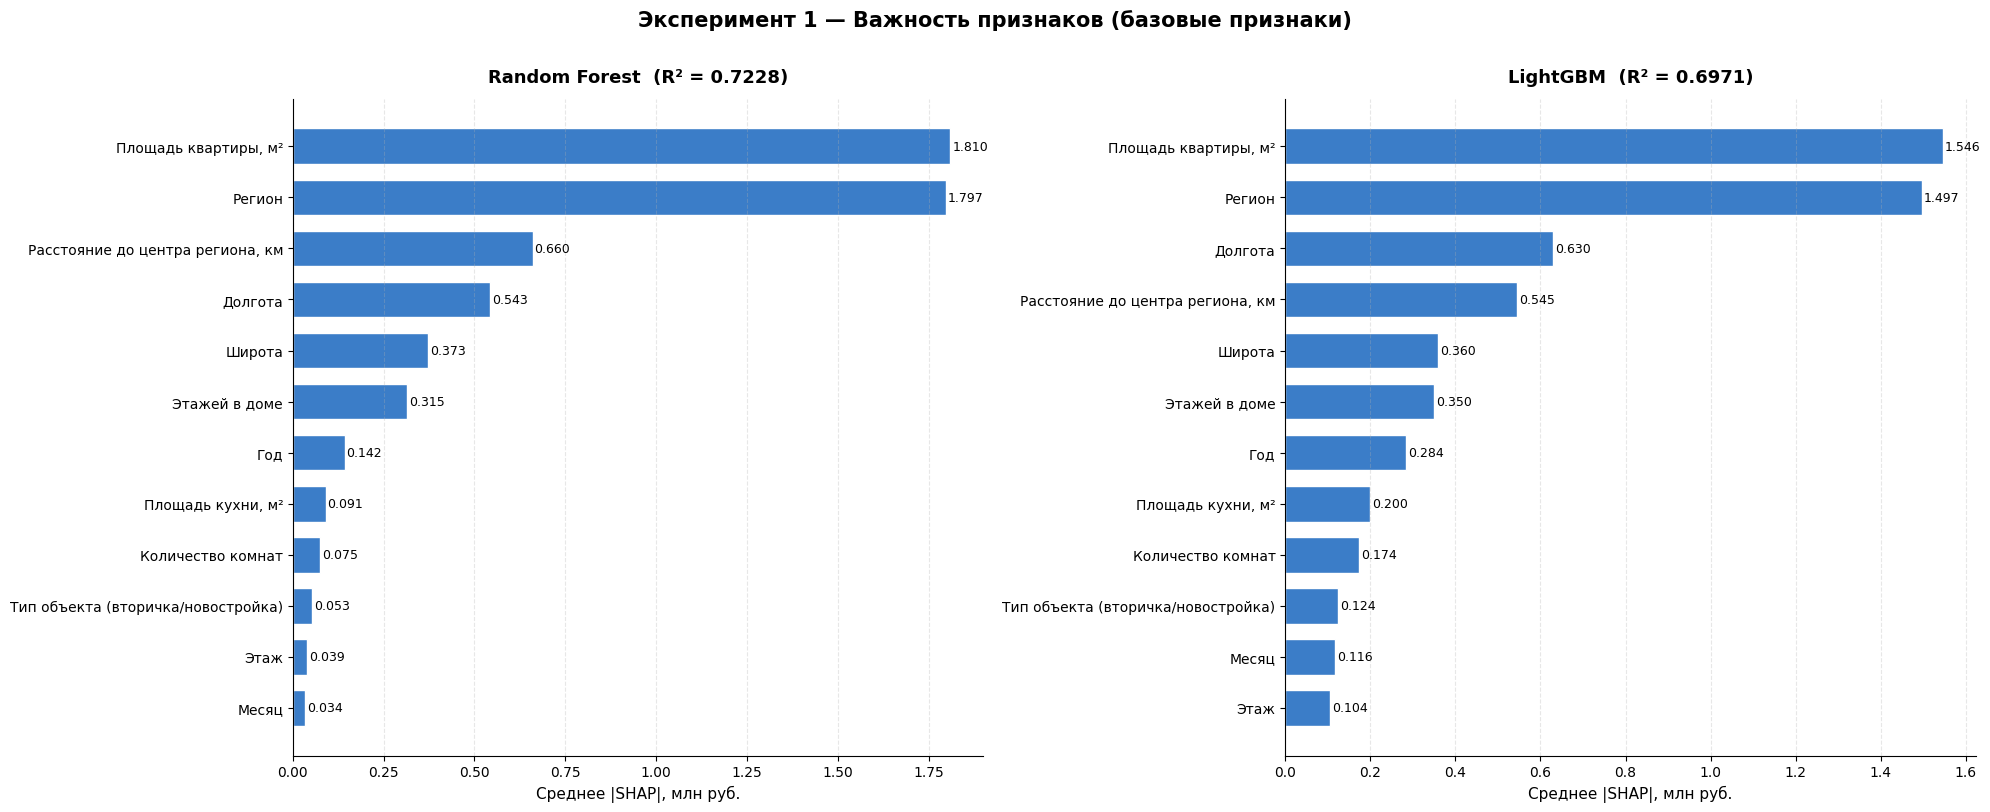

График сохранён: results/figures/exp1_feature_importance.png


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(20, 8))
fig.suptitle('Эксперимент 1 — Важность признаков (базовые признаки)',
             fontsize=15, fontweight='bold', y=1.01)

shap1_rf   = plot_shap(rf1,   pd.DataFrame(X_te1_imp, columns=FEATURES_EXP1),
                        FEATURES_EXP1, 'Random Forest  (R² = 0.7228)', ax=axes[0])

shap1_lgbm = plot_shap(lgbm1, X_te1, FEATURES_EXP1,
                        'LightGBM  (R² = 0.6971)', ax=axes[1])

plt.tight_layout()
plt.savefig('../results/figures/exp1_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print('График сохранён: results/figures/exp1_feature_importance.png')

## 5. Эксперимент 2 — важность признаков (Random Forest и CatBoost)

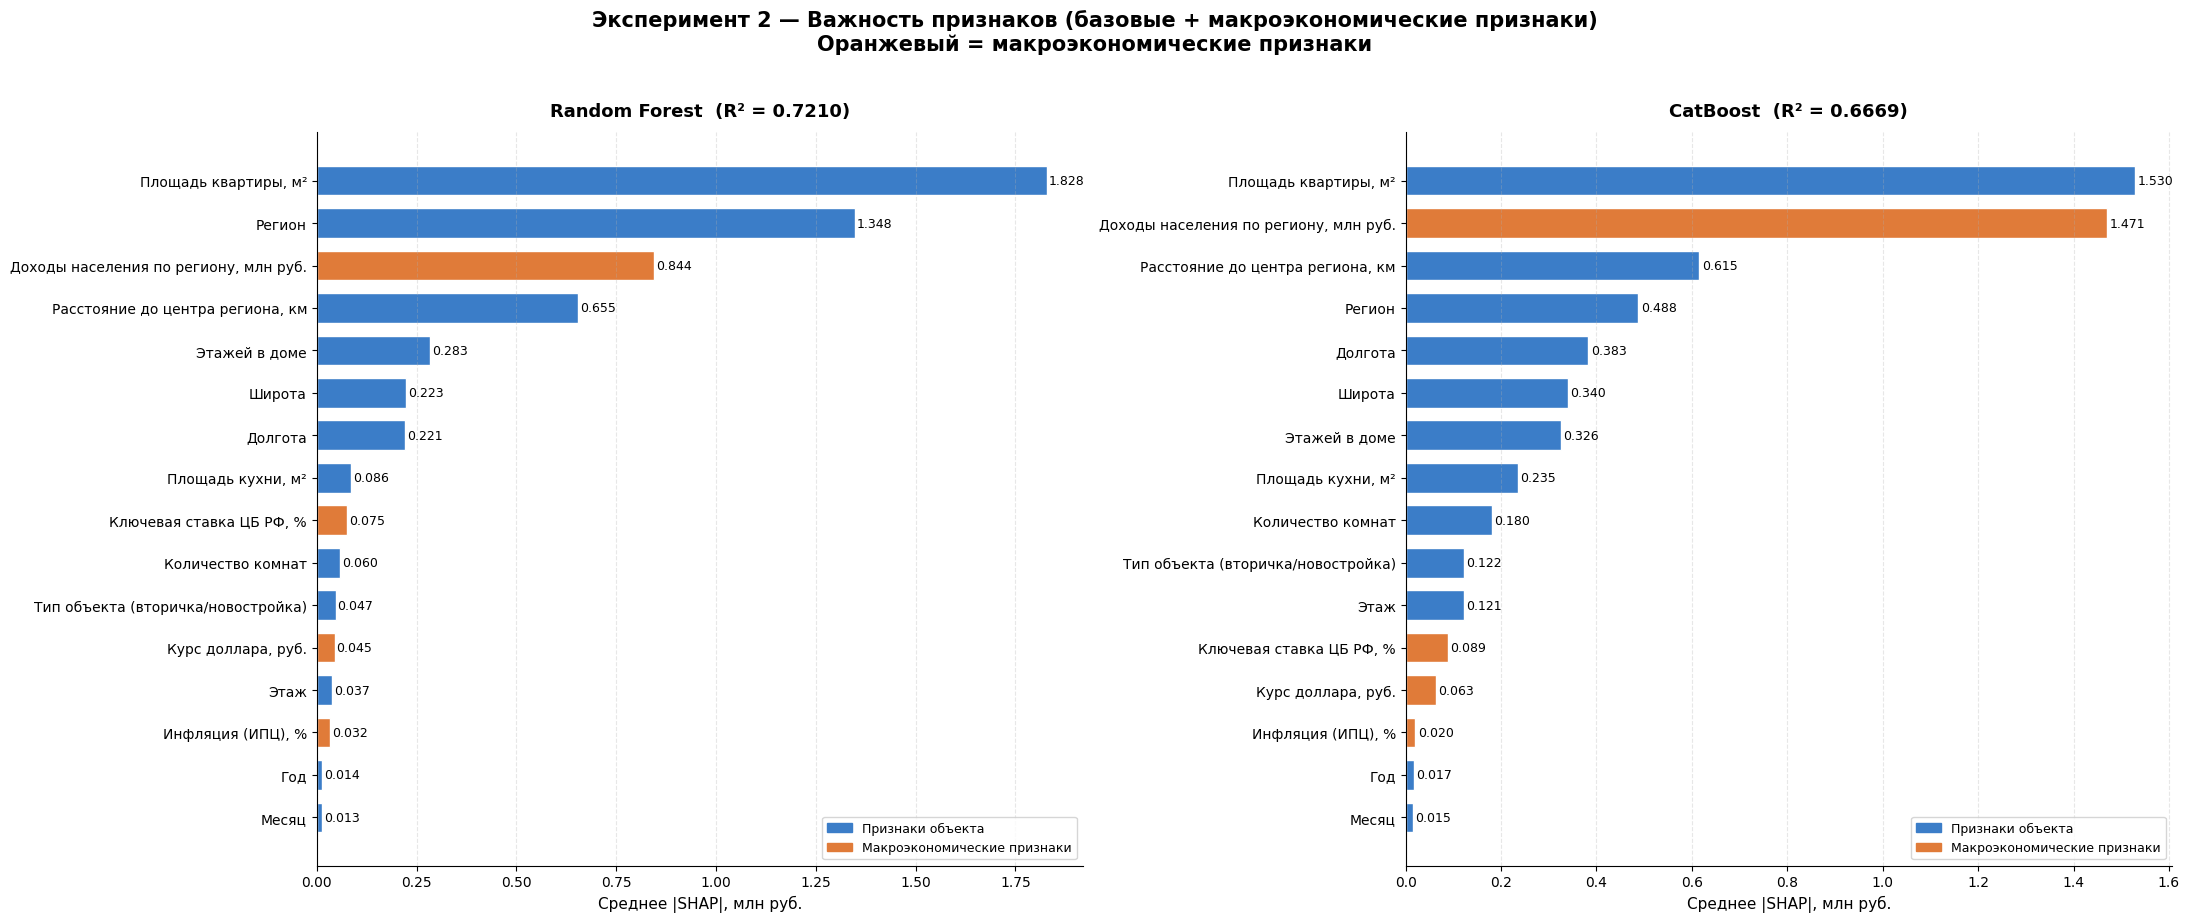

График сохранён: results/figures/exp2_feature_importance.png


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(22, 9))
fig.suptitle('Эксперимент 2 — Важность признаков (базовые + макроэкономические признаки)\n'
             'Оранжевый = макроэкономические признаки',
             fontsize=15, fontweight='bold', y=1.02)

shap2_rf = plot_shap(rf2,  pd.DataFrame(X_te2_imp, columns=FEATURES_EXP2),
                     FEATURES_EXP2, 'Random Forest  (R² = 0.7210)',
                     is_macro=True, ax=axes[0])

shap2_cb = plot_shap(cb2,  X_te2, FEATURES_EXP2,
                     'CatBoost  (R² = 0.6669)',
                     is_macro=True, ax=axes[1])

plt.tight_layout()
plt.savefig('../results/figures/exp2_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print('График сохранён: results/figures/exp2_feature_importance.png')

## 6. Сравнительная таблица — топ признаков по моделям

In [8]:
def top_features(df_shap, n=5):
    return df_shap.sort_values('shap', ascending=False).head(n)[['feature', 'shap']].assign(
        shap=lambda x: (x['shap'] / 1e6).round(3)
    ).rename(columns={'feature': 'Признак', 'shap': '|SHAP|, млн руб.'})

print('═' * 55)
print('ТОП-5 признаков — Эксперимент 1')
print('─' * 55)
print('Random Forest:')
print(top_features(shap1_rf).to_string(index=False))
print()
print('LightGBM:')
print(top_features(shap1_lgbm).to_string(index=False))

print()
print('═' * 55)
print('ТОП-5 признаков — Эксперимент 2')
print('─' * 55)
print('Random Forest:')
print(top_features(shap2_rf).to_string(index=False))
print()
print('CatBoost:')
print(top_features(shap2_cb).to_string(index=False))

═══════════════════════════════════════════════════════
ТОП-5 признаков — Эксперимент 1
───────────────────────────────────────────────────────
Random Forest:
                         Признак  |SHAP|, млн руб.
            Площадь квартиры, м²             1.810
                          Регион             1.797
Расстояние до центра региона, км             0.660
                         Долгота             0.543
                          Широта             0.373

LightGBM:
                         Признак  |SHAP|, млн руб.
            Площадь квартиры, м²             1.546
                          Регион             1.497
                         Долгота             0.630
Расстояние до центра региона, км             0.545
                          Широта             0.360

═══════════════════════════════════════════════════════
ТОП-5 признаков — Эксперимент 2
───────────────────────────────────────────────────────
Random Forest:
                              Признак  |SHAP|, млн руб.
  